Este notebook muestra la eficacia de usar pipe line para automatizar el proceso. Ademas muestra distintas opciones a usar en validación cruzada.  

In [8]:
import numpy as np
from math import sqrt

from sklearn import datasets
import sklearn.metrics as metrics

# Pipeline: encadena pasos de preprocesamiento + modelo en un solo objeto
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsRegressor    # modelo KNN
from sklearn.preprocessing import StandardScaler     # estandarización
from sklearn.feature_selection import (
    f_regression,       # criterio estadístico para selección de features (correlación con y)
    SelectPercentile    # selecciona el X% de mejores features según el criterio
)
from sklearn.model_selection import (
    cross_val_predict,  # predicciones por validación cruzada
    KFold               # partición en K bolsas
)

# Módulo personalizado con funciones de evaluación (plot_bisectriz, etc.)
from evaluacion_funciones import * # script .py - debe estar en local

import warnings
warnings.filterwarnings("ignore")

In [11]:
# Carga de datos.
dataset = datasets.fetch_california_housing()
X = dataset.data
y = dataset.target
print(np.shape(X))

(20640, 8)


In [12]:
# Métricas de evaluación.
metricas = {
  'MAE':  metrics.mean_absolute_error,
  'RMSE': lambda y, y_pred:
          sqrt(metrics.mean_squared_error(y, y_pred)),
  'MAPE': lambda y, y_pred:
          np.mean(np.abs((y - y_pred) / y)) * 100,
  'R2':   metrics.r2_score}

In [16]:
# INICIALIZACIÓN DE LOS ALGORITMOS

k = 10
base = 'KNN' + str(k)  # nombre identificador → 'KNN10'

# Diccionario vacío donde se guardarán los distintos pipelines/modelos
algoritmos = {}

In [18]:
# ALGORITMO 1: KNN sin preprocesamiento
# Se añade al diccionario con la clave 'KNN10'
algoritmos[base] = KNeighborsRegressor(n_neighbors=k)

Es el modelo más básico — sin estandarización ni selección de features. Servirá como baseline para comparar con los siguientes pipelines.

In [19]:
# ALGORITMO 2: PIPELINE con Estandarización + KNN

# Un Pipeline encadena pasos secuenciales: cada paso transforma la salida del anterior
pasos = [
    ('estandarizacion', StandardScaler()),          # paso 1: estandarizar features
    ('reg',             algoritmos['KNN'+str(k)])   # paso 2: aplicar KNN
]

# Se guarda con clave 'Est+KNN10'
algoritmos['Est+'+base] = Pipeline(pasos)

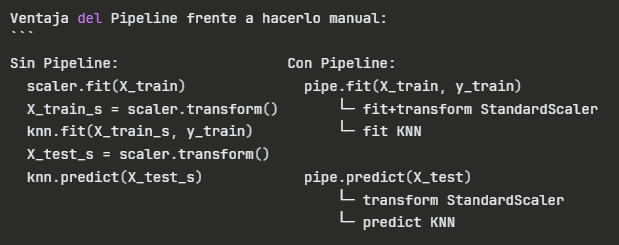

In [20]:
# ALGORITMO 3: PIPELINE con Estandarización + Selección de Atributos + KNN

pasos = [
    ('estandarizacion', StandardScaler()),                             # paso 1: estandarizar
    ('selatr', SelectPercentile(score_func=f_regression,               # paso 2: selección de features
                                percentile=10)),                       #   → conserva el 10% mejores
    ('reg', algoritmos['KNN'+str(k)])                                  # paso 3: KNN
]

In [21]:
# ALGORITMO 4: PIPELINE con Estandarización + Selección de Atributos + KNN con distancia Manhattan

pasos = [
    ('estandarizacion', StandardScaler()),
    ('selatr', SelectPercentile(score_func=f_regression, percentile=10)),
    ('reg', KNeighborsRegressor(n_neighbors=k, p=1))   # p=1 → distancia Manhattan
]

# Se guarda con clave 'Est+SelAtr+KNN10(p=1)'
algoritmos['Est+SelAtr+'+base+'(p=1)'] = Pipeline(pasos)

In [22]:
# VALIDACIÓN CRUZADA PARA TODOS LOS ALGORITMOS

y_pred = {}  # diccionario para guardar las predicciones de cada algoritmo

# Iterar sobre cada algoritmo definido en el diccionario
for nombre, alg in algoritmos.items():
    # cross_val_predict devuelve la predicción de cada muestra
    # cuando era parte del conjunto de validación en su bolsa
    # cv=KFold(10) → 10 bolsas aleatorias con semilla 42
    y_pred[nombre] = cross_val_predict(alg, X, y,
                                       cv=KFold(n_splits=10, shuffle=True, random_state=42))

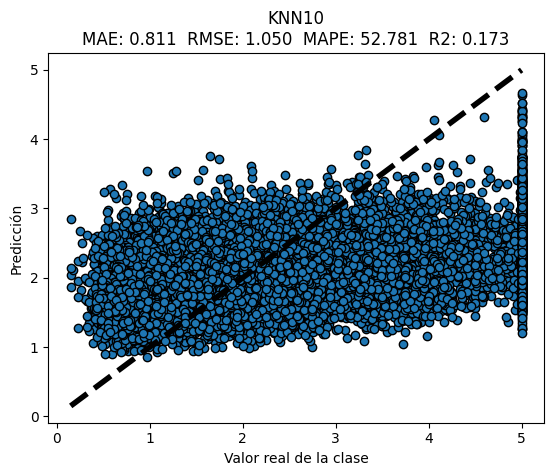

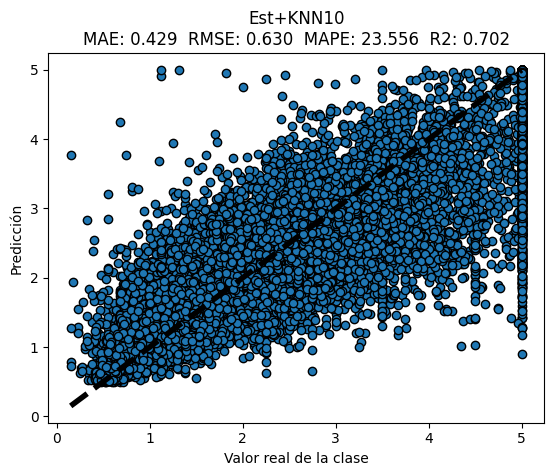

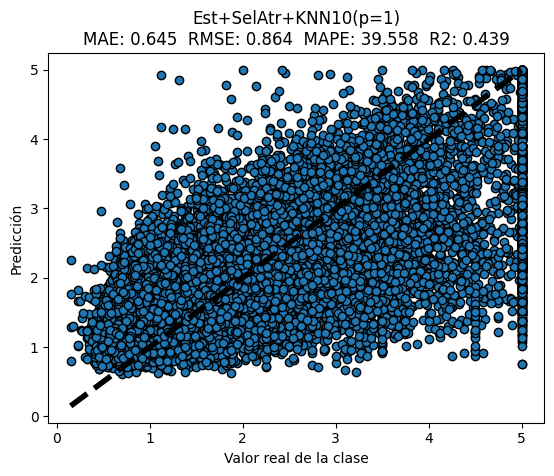

In [23]:
# EVALUACIÓN Y VISUALIZACIÓN DE TODOS LOS ALGORITMOS

for nombre, alg in algoritmos.items():
    # evaluacion() → función de evaluacion_funciones.py
    # calcula las métricas (MAE, RMSE, MAPE...) comparando y real vs y predicho
    results = evaluacion(y, y_pred[nombre], metricas)

    # grafica_real_vs_pred() → función de evaluacion_funciones.py
    # muestra la bisectriz + métricas para cada algoritmo
    grafica_real_vs_pred(y, y_pred[nombre], results, nombre)